# Data Cleaning & Exploratory Data Analysis (EDA) Pipeline
### Comprehensive Workflow: Ingestion, Quality Auditing, Transformation, Outlier Handling, and Visual Analysis

---

## 1. Project Overview & Objectives
Real-world datasets regularly suffer from data quality anomalies—such as **missing fields**, **redundant records**, **conflicting types**, and **extreme outliers**—which can corrupt statistical analysis and machine learning models.

This notebook executes an end-to-end Data Cleaning and Exploratory Data Analysis (EDA) workflow on `sample_data.csv`, addressing:
1. **Structural Auditing**: Identifying missing values, duplicate entries, and incorrect data types.
2. **Standardization & Type Casting**: Normalizing text fields, dates, booleans, and currency strings.
3. **Outlier & Logical Anomaly Remediation**: Handling extreme and logically impossible observations.
4. **Data Imputation**: Applying domain-aware median and mode imputation.
5. **Exploratory Data Analysis & Visualizations**: Presenting summary statistics, correlations, and distribution plots.


In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Styling configuration
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


---
## 2. Raw Data Ingestion & Initial Quality Audit
We begin by ingesting `sample_data.csv` and inspecting its schema, dimensions, and data quality issues.


In [2]:
# Load the raw dataset
raw_df = pd.read_csv("sample_data.csv")
print(f"Raw Dataset Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
raw_df.head(10)

Raw Dataset Shape: 33 rows, 10 columns


,employee_id,name,age,gender,department,salary,join_date,years_of_experience,performance_score,remote_worker
0,EMP001,John Doe,29,Male,Engineering,"$75,000",2020-03-15,4,85,True
1,EMP002,Jane Smith,34,F,Marketing,"$82,000",2018-07-22,8,92,FALSE
2,EMP003,Robert Brown,250,Male,Sales,"$61,000",2022-01-10,2,-15,No
3,EMP004,Emily Davis,28,Female,Human Resources,"$58,000",15/04/2021,5,78,Yes
4,EMP005,Michael Wilson,NaN,M,Engineering,"$105,000",2016-11-01,11,88,1
5,EMP006,Sarah Taylor,31,female,Finance,"$95,000.50",2019-09-18,7,90,0
6,EMP007,David Anderson,-5,M,Sales,"-$45,000",2023-02-01,1,65,False
7,EMP008,Jessica Thomas,42,Female,Humman Resources,"$72,000",2015-05-30,15,82,Yes
8,EMP009,James Jackson,36,Male,Finance,"$88,000",2017-08-14,9,95,True
9,EMP010,Patricia White,29,F,Marketing,Unknown,2021-12-05,4,74,False


In [3]:
# Inspect data types and non-null counts
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   employee_id          33 non-null     str  
 1   name                 33 non-null     str  
 2   age                  30 non-null     str  
 3   gender               33 non-null     str  
 4   department           33 non-null     str  
 5   salary               32 non-null     str  
 6   join_date            33 non-null     str  
 7   years_of_experience  33 non-null     int64
 8   performance_score    33 non-null     int64
 9   remote_worker        33 non-null     str  
dtypes: int64(2), str(8)
memory usage: 2.7 KB


In [4]:
# Check for missing values across all columns
raw_missing = raw_df.isnull().sum()
raw_missing_pct = (raw_df.isnull().sum() / len(raw_df)) * 100
pd.DataFrame({"Missing Values": raw_missing, "Percentage (%)": raw_missing_pct})

,Missing Values,Percentage (%)
employee_id,0,0.000000
name,0,0.000000
age,3,9.090909
gender,0,0.000000
department,0,0.000000
salary,1,3.030303
join_date,0,0.000000
years_of_experience,0,0.000000
performance_score,0,0.000000
remote_worker,0,0.000000


In [5]:
# Check for duplicate rows
raw_duplicates = raw_df.duplicated().sum()
print(f"Total duplicate rows detected: {raw_duplicates}")
if raw_duplicates > 0:
    display(raw_df[raw_df.duplicated(keep=False)])

Total duplicate rows detected: 3


,employee_id,name,age,gender,department,salary,join_date,years_of_experience,performance_score,remote_worker
0,EMP001,John Doe,29,Male,Engineering,"$75,000",2020-03-15,4,85,True
5,EMP006,Sarah Taylor,31,female,Finance,"$95,000.50",2019-09-18,7,90,0
20,EMP001,John Doe,29,Male,Engineering,"$75,000",2020-03-15,4,85,True
27,EMP006,Sarah Taylor,31,female,Finance,"$95,000.50",2019-09-18,7,90,0
31,EMP030,Gary Roberts,44,Male,Finance,"$108,000",2014-11-20,16,92,False
32,EMP030,Gary Roberts,44,Male,Finance,"$108,000",2014-11-20,16,92,False


---
## 3. Data Cleaning & Transformation Pipeline

### Key Anomalies Identified:
1. **Duplicate Entries**: Multiple rows share identical values across all attributes (`EMP001`, `EMP006`, `EMP030`).
2. **Missing Representations**: Blanks and string placeholders (`'?'`, `'Unknown'`, `'N/A'`).
3. **Type Mismatches**:
   - `salary` stored as string with `$` and commas.
   - `age` contains written words (`'thirty'`).
   - `join_date` uses mixed formats (`YYYY-MM-DD`, `DD/MM/YYYY`, `MM-DD-YYYY`) and invalid text (`'invalid_date'`).
   - `remote_worker` has mixed encodings (`'True'`, `'FALSE'`, `'Yes'`, `'No'`, `'1'`, `'0'`).
4. **Domain Outliers & Logical Inconsistencies**:
   - `age`: values of `250` and `-5`.
   - `salary`: values of `-$45,000` and `$25,000,000`.
   - `years_of_experience`: `-3` and `65` (exceeding employee's age).
   - `performance_score`: `-15` and `999`.


In [6]:
# Step 3.1: Reload with standardized null values and drop exact duplicates
na_sentinels = ["", " ", "NA", "N/A", "null", "None", "?", "Unknown", "invalid_date"]
df_clean = pd.read_csv("sample_data.csv", na_values=na_sentinels, keep_default_na=True)

initial_count = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Removed {initial_count - len(df_clean)} duplicate rows. Current count: {len(df_clean)} rows.")

Removed 3 duplicate rows. Current count: 30 rows.


In [7]:
# Step 3.2: Type Conversion & Text Standardization
# Standardize string columns
str_cols = df_clean.select_dtypes(include=object).columns
for col in str_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().replace("nan", np.nan)

# Age: map word representation to integer and convert to float
df_clean["age"] = df_clean["age"].replace({"thirty": 30, "twenty": 20, "forty": 40})
df_clean["age"] = pd.to_numeric(df_clean["age"], errors="coerce")

# Salary: strip currency signs and commas, cast to float
df_clean["salary"] = (
    df_clean["salary"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df_clean["salary"] = pd.to_numeric(df_clean["salary"], errors="coerce")

# Join Date: parse mixed date formats into datetime
df_clean["join_date"] = pd.to_datetime(df_clean["join_date"], format="mixed", errors="coerce")

# Gender: map shorthand/casing
gender_map = {"M": "Male", "Male": "Male", "F": "Female", "female": "Female", "Female": "Female"}
df_clean["gender"] = df_clean["gender"].map(gender_map)

# Department: fix typos and abbreviations
dept_map = {
    "HR": "Human Resources",
    "Humman Resources": "Human Resources",
    "Human Resources": "Human Resources",
    "Engineering": "Engineering",
    "Marketing": "Marketing",
    "Finance": "Finance",
    "IT": "IT",
    "Sales": "Sales"
}
df_clean["department"] = df_clean["department"].replace(dept_map)

# Remote Worker: map boolean representations
bool_map = {
    "True": True, "TRUE": True, "true": True, "1": True, 1: True, "Yes": True, "yes": True,
    "False": False, "FALSE": False, "false": False, "0": False, 0: False, "No": False, "no": False
}
df_clean["remote_worker"] = df_clean["remote_worker"].map(bool_map)

print("Type conversions and text standardization completed.")

Type conversions and text standardization completed.


C:\Users\Admin\AppData\Local\Temp\ipykernel_5880\300706757.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_clean.select_dtypes(include=object).columns


In [8]:
# Step 3.3: Outlier & Anomaly Detection & Replacement with NaN
# Age: valid working age between 18 and 70
invalid_age = (df_clean["age"] < 18) | (df_clean["age"] > 70)
print(f"Flagged invalid ages: {df_clean.loc[invalid_age, 'age'].dropna().tolist()}")
df_clean.loc[invalid_age, "age"] = np.nan

# Salary: valid range > 0 and <= $1,000,000
invalid_salary = (df_clean["salary"] <= 0) | (df_clean["salary"] > 1_000_000)
print(f"Flagged invalid salaries: {df_clean.loc[invalid_salary, 'salary'].dropna().tolist()}")
df_clean.loc[invalid_salary, "salary"] = np.nan

# Experience: must be >= 0 and <= (age - 16)
invalid_exp = (df_clean["years_of_experience"] < 0) | (
    df_clean["age"].notnull() & (df_clean["years_of_experience"] > (df_clean["age"] - 16))
)
print(f"Flagged invalid experience: {df_clean.loc[invalid_exp, 'years_of_experience'].dropna().tolist()}")
df_clean.loc[invalid_exp, "years_of_experience"] = np.nan

# Performance score: range [0, 100]
invalid_score = (df_clean["performance_score"] < 0) | (df_clean["performance_score"] > 100)
print(f"Flagged invalid performance scores: {df_clean.loc[invalid_score, 'performance_score'].dropna().tolist()}")
df_clean.loc[invalid_score, "performance_score"] = np.nan

Flagged invalid ages: [250.0, -5.0]
Flagged invalid salaries: [-45000.0, 25000000.0]
Flagged invalid experience: [65, -3]
Flagged invalid performance scores: [-15, 999]


In [9]:
# Step 3.4: Missing Value Imputation
# Impute numerical features with median
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median()).astype(int)

# Salary imputed using department-specific median
dept_median = df_clean.groupby("department")["salary"].transform("median")
df_clean["salary"] = df_clean["salary"].fillna(dept_median).fillna(df_clean["salary"].median()).round(2)

df_clean["years_of_experience"] = df_clean["years_of_experience"].fillna(df_clean["years_of_experience"].median()).astype(int)
df_clean["performance_score"] = df_clean["performance_score"].fillna(df_clean["performance_score"].median()).astype(int)

# Impute categoricals with mode
df_clean["gender"] = df_clean["gender"].fillna(df_clean["gender"].mode()[0])
df_clean["remote_worker"] = df_clean["remote_worker"].fillna(df_clean["remote_worker"].mode()[0]).astype(bool)

# Impute missing date with median date
median_date = df_clean["join_date"].dropna().quantile(0.5, interpolation="midpoint")
df_clean["join_date"] = df_clean["join_date"].fillna(median_date)

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
employee_id            0
name                   0
age                    0
gender                 0
department             0
salary                 0
join_date              0
years_of_experience    0
performance_score      0
remote_worker          0
dtype: int64


In [10]:
# Step 3.5: Save Cleaned Dataset
# Format join_date as ISO string for clean export
df_export = df_clean.copy()
df_export["join_date"] = df_export["join_date"].dt.strftime("%Y-%m-%d")
df_export.to_csv("cleaned_data.csv", index=False)
print("Cleaned data successfully validated and saved to 'cleaned_data.csv'.")
df_export.head()

Cleaned data successfully validated and saved to 'cleaned_data.csv'.


,employee_id,name,age,gender,department,salary,join_date,years_of_experience,performance_score,remote_worker
0,EMP001,John Doe,29,Male,Engineering,75000.0,2020-03-15,4,85,True
1,EMP002,Jane Smith,34,Female,Marketing,82000.0,2018-07-22,8,92,False
2,EMP003,Robert Brown,33,Male,Sales,61000.0,2022-01-10,2,85,False
3,EMP004,Emily Davis,28,Female,Human Resources,58000.0,2021-04-15,5,78,True
4,EMP005,Michael Wilson,33,Male,Engineering,105000.0,2016-11-01,11,88,True


---
## 4. Summary Statistics & Exploratory Data Analysis
With a clean dataset, we compute descriptive statistics and evaluate inter-departmental variations.


In [11]:
# Summary statistics for numerical variables
df_clean.describe().round(2)

,age,salary,join_date,years_of_experience,performance_score
count,30.00,30.00,30,30.00,30.00
mean,34.20,84366.68,2018-10-09 13:36:00,8.40,84.27
min,22.00,55000.00,2010-09-15 00:00:00,1.00,65.00
25%,29.25,70500.00,2016-10-15 12:00:00,4.00,80.25
50%,33.00,84500.00,2019-10-15 00:00:00,7.00,85.00
75%,37.75,97250.12,2021-04-14 18:00:00,11.75,89.75
max,52.00,120000.00,2023-05-02 00:00:00,25.00,96.00
std,7.01,18191.49,NaN,6.00,7.88


In [12]:
# Department-level aggregation
dept_summary = df_clean.groupby("department").agg(
    headcount=("employee_id", "count"),
    avg_salary=("salary", "mean"),
    median_salary=("salary", "median"),
    avg_experience=("years_of_experience", "mean"),
    avg_performance=("performance_score", "mean")
).reset_index()
dept_summary.style.format({
    "avg_salary": "${:,.2f}",
    "median_salary": "${:,.2f}",
    "avg_experience": "{:.1f} yrs",
    "avg_performance": "{:.1f}"
})

,department,headcount,avg_salary,median_salary,avg_experience,avg_performance
0,Engineering,7,"$85,000.00","$84,000.00",7.1 yrs,85.6
1,Finance,6,"$101,666.75","$102,000.00",13.0 yrs,91.5
2,Human Resources,4,"$90,000.00","$91,000.00",15.8 yrs,86.8
3,IT,4,"$86,500.00","$89,000.00",6.0 yrs,83.5
4,Marketing,4,"$80,500.00","$82,000.00",7.0 yrs,82.8
5,Sales,5,"$59,600.00","$60,000.00",1.8 yrs,73.6


In [13]:
# Remote vs On-site employee analysis
remote_summary = df_clean.groupby("remote_worker").agg(
    count=("employee_id", "count"),
    avg_salary=("salary", "mean"),
    avg_performance=("performance_score", "mean"),
    avg_experience=("years_of_experience", "mean")
).rename(index={True: "Remote", False: "On-site"})
remote_summary.round(2)

,count,avg_salary,avg_performance,avg_experience
remote_worker,,,,
On-site,14,87142.89,84.43,8.71
Remote,16,81937.50,84.12,8.12


In [14]:
# Correlation Matrix
num_cols = ["age", "salary", "years_of_experience", "performance_score"]
corr_matrix = df_clean[num_cols].corr()
corr_matrix.round(3)

,age,salary,years_of_experience,performance_score
age,1.000,0.773,0.905,0.671
salary,0.773,1.000,0.840,0.796
years_of_experience,0.905,0.840,1.000,0.736
performance_score,0.671,0.796,0.736,1.000


---
## 5. Visualizations & Analytical Insights
Below are the high-resolution charts generated from the analysis pipeline (stored in [`plots/`](plots/)).

### 5.1 Numerical Feature Distributions
Features show realistic unimodal distributions after outlier remediation:
- **Age**: Clustered in the late 20s to early 40s (median: 33).
- **Salary**: Typically spans \$55,000 to \$120,000, with an overall median of \$84,500.
- **Experience**: Concentrated between 3 and 15 years.
- **Performance**: High clustering in the 75–95 range.


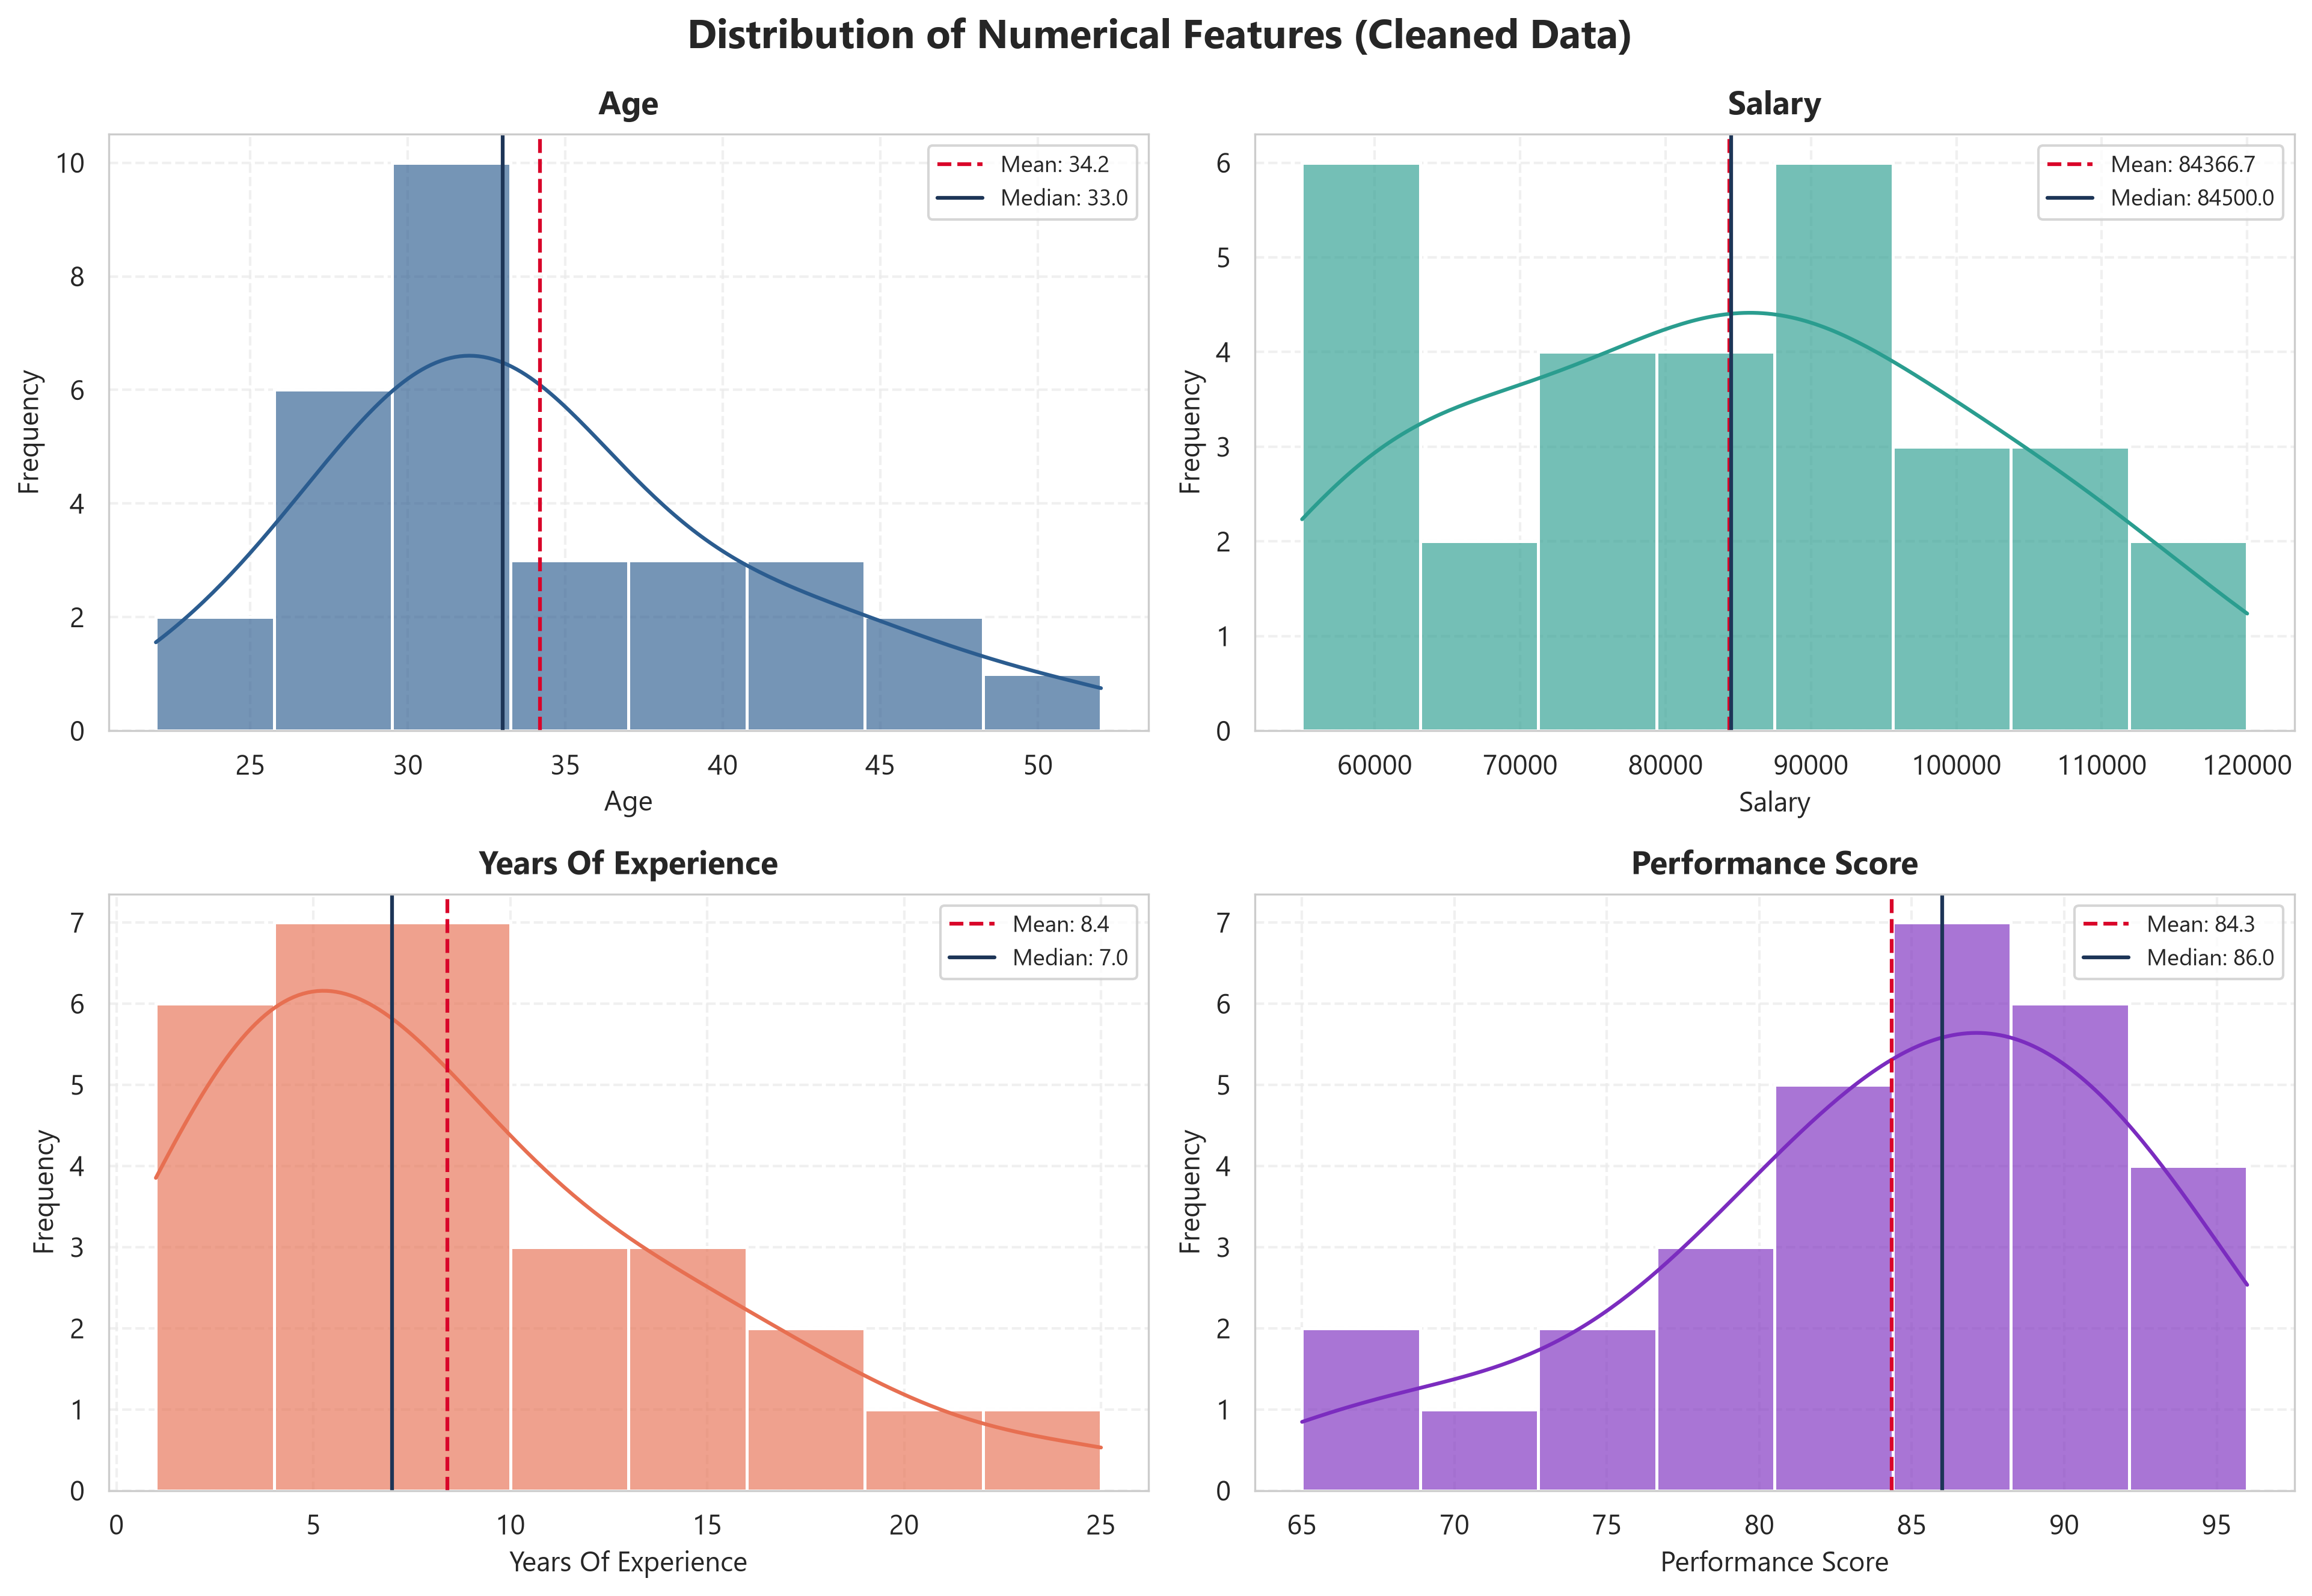

In [15]:
# Display Numerical Histograms
display(Image(filename="plots/histograms_numerical.png"))

### 5.2 Outlier Verification & Salary by Department
Box plots verify that extreme anomalies (negative values, age 250, \$25M salary, score 999) have been cleanly imputed, leaving standard realistic IQR bounds.


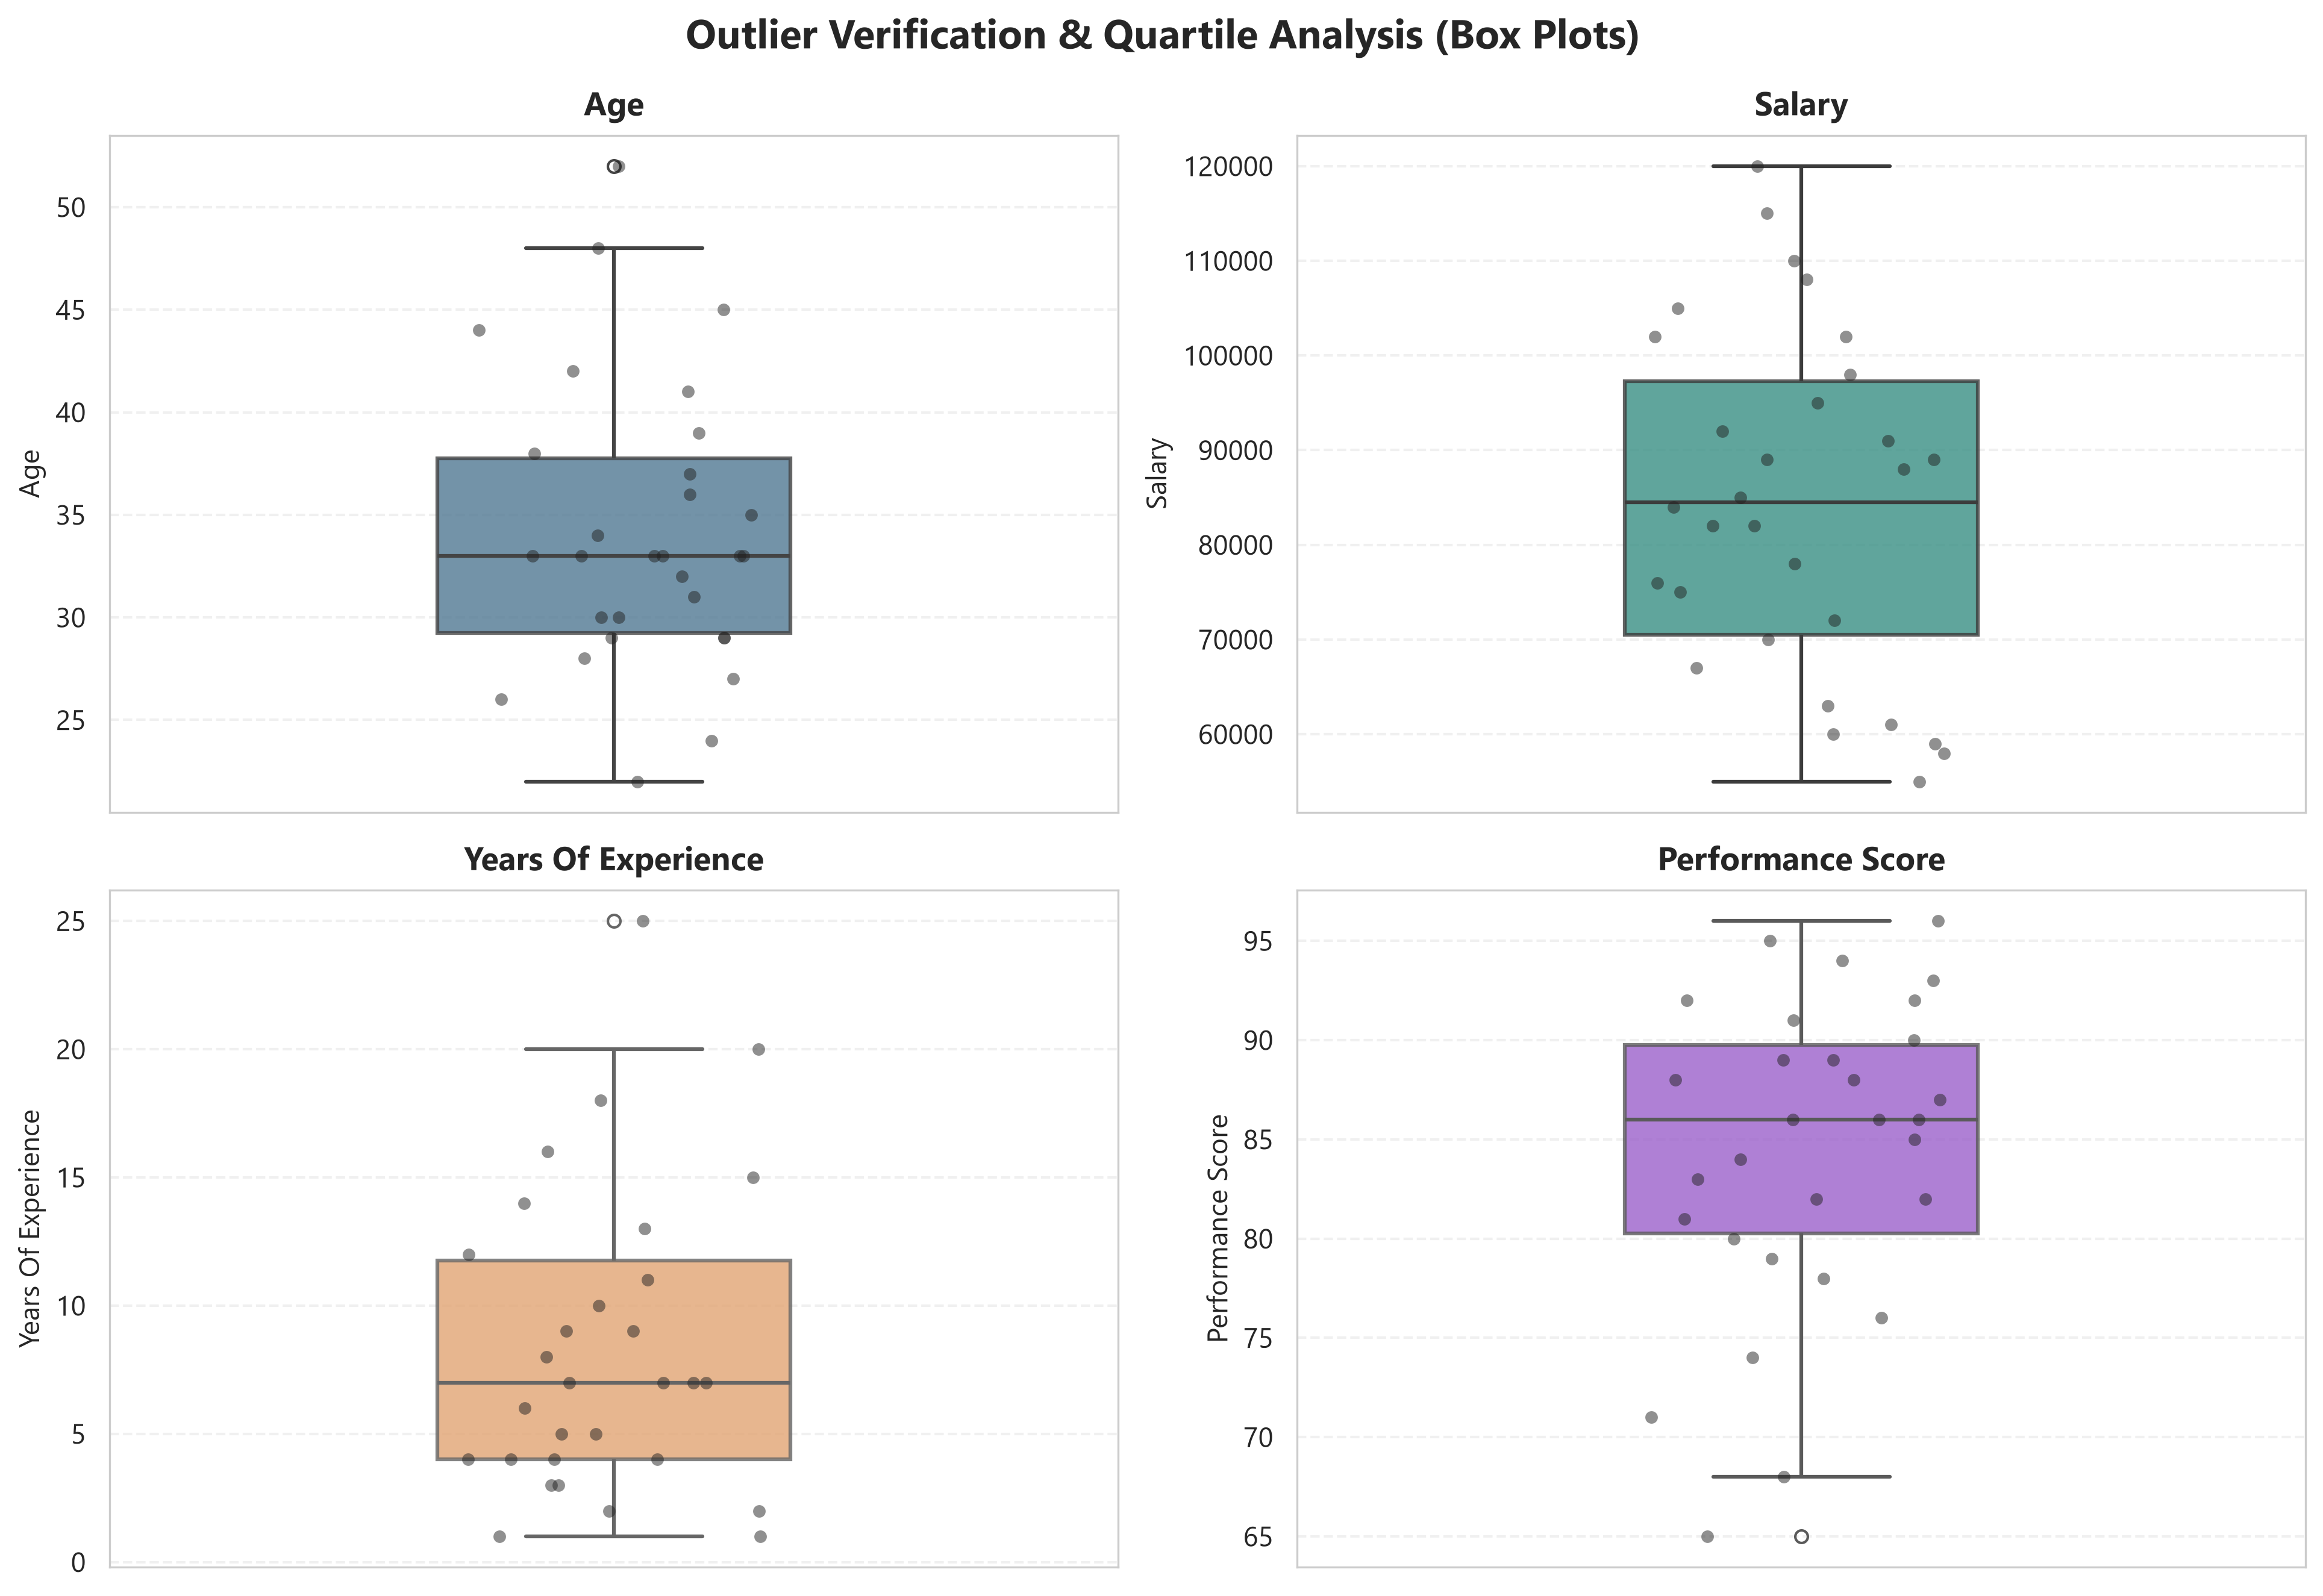

In [16]:
# Display Box Plots for Outlier Checks
display(Image(filename="plots/boxplots_outliers.png"))

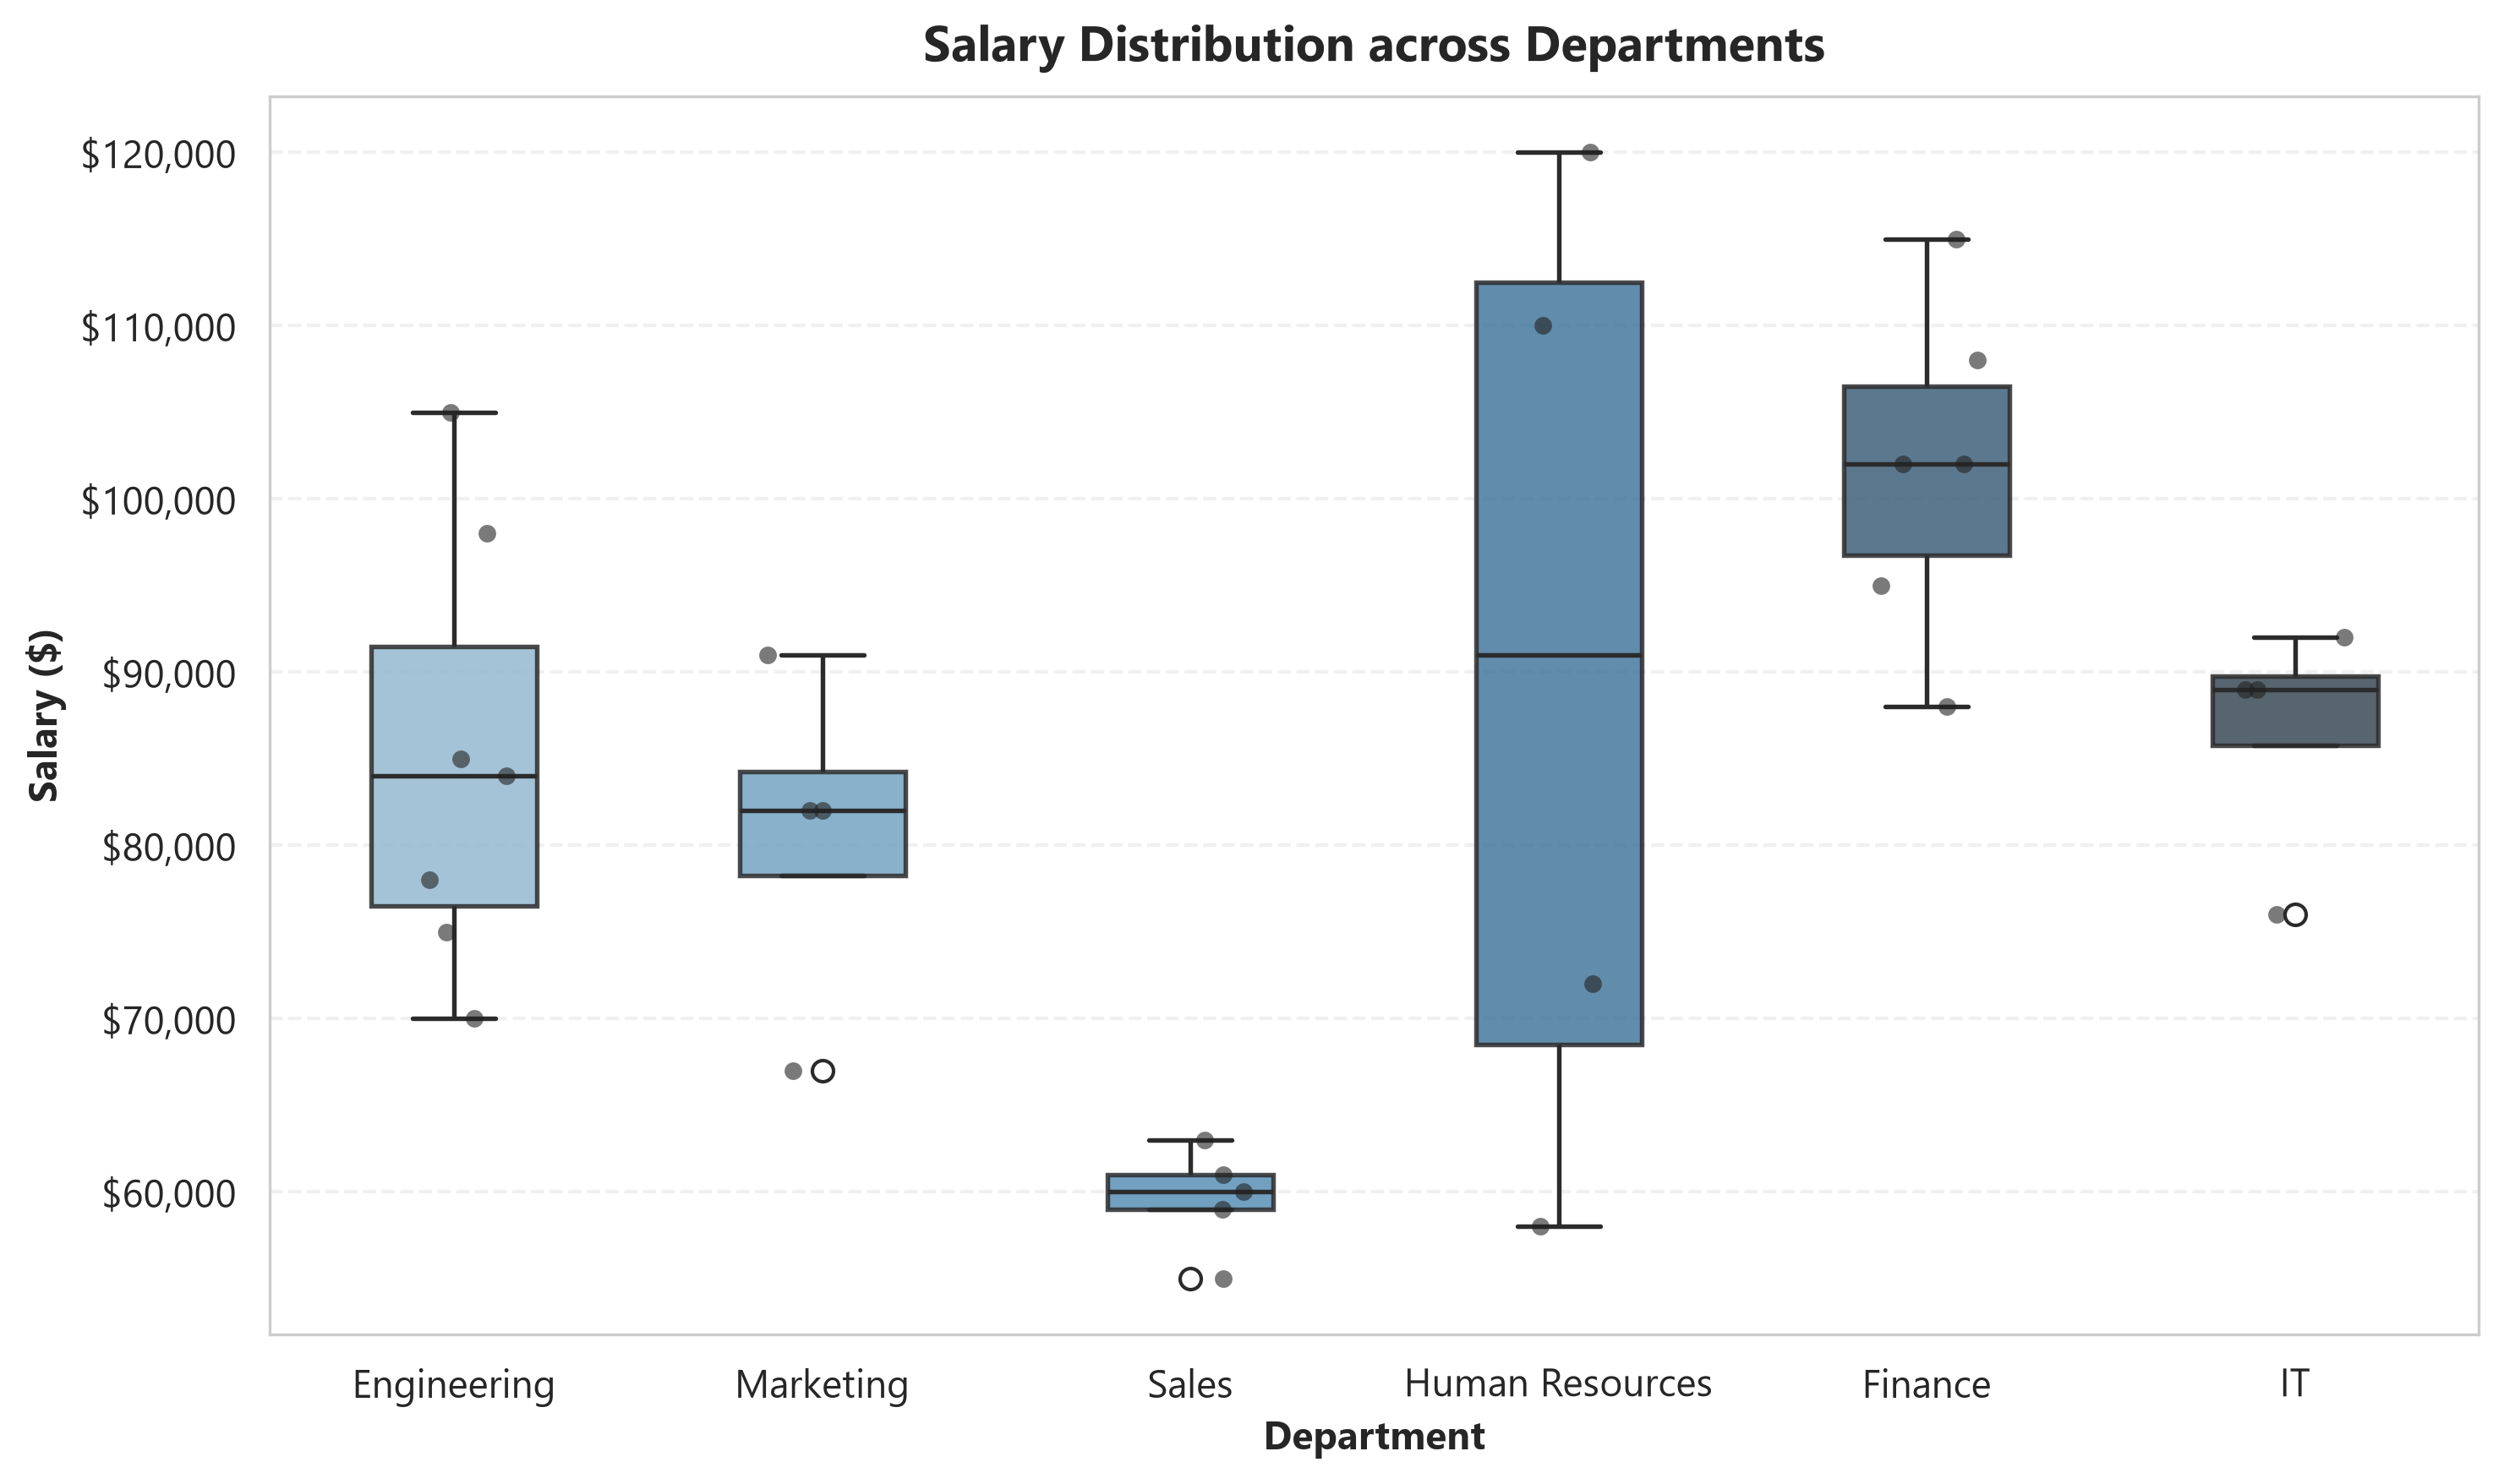

In [17]:
# Display Departmental Salary Distribution
display(Image(filename="plots/boxplots_salary_by_department.png"))

### 5.3 Categorical Composition
- **Department**: Balanced representation across Engineering, Finance, Sales, IT, Marketing, and Human Resources.
- **Gender**: Representative gender balance.
- **Work Model**: Healthy mix between remote and on-site workforce.


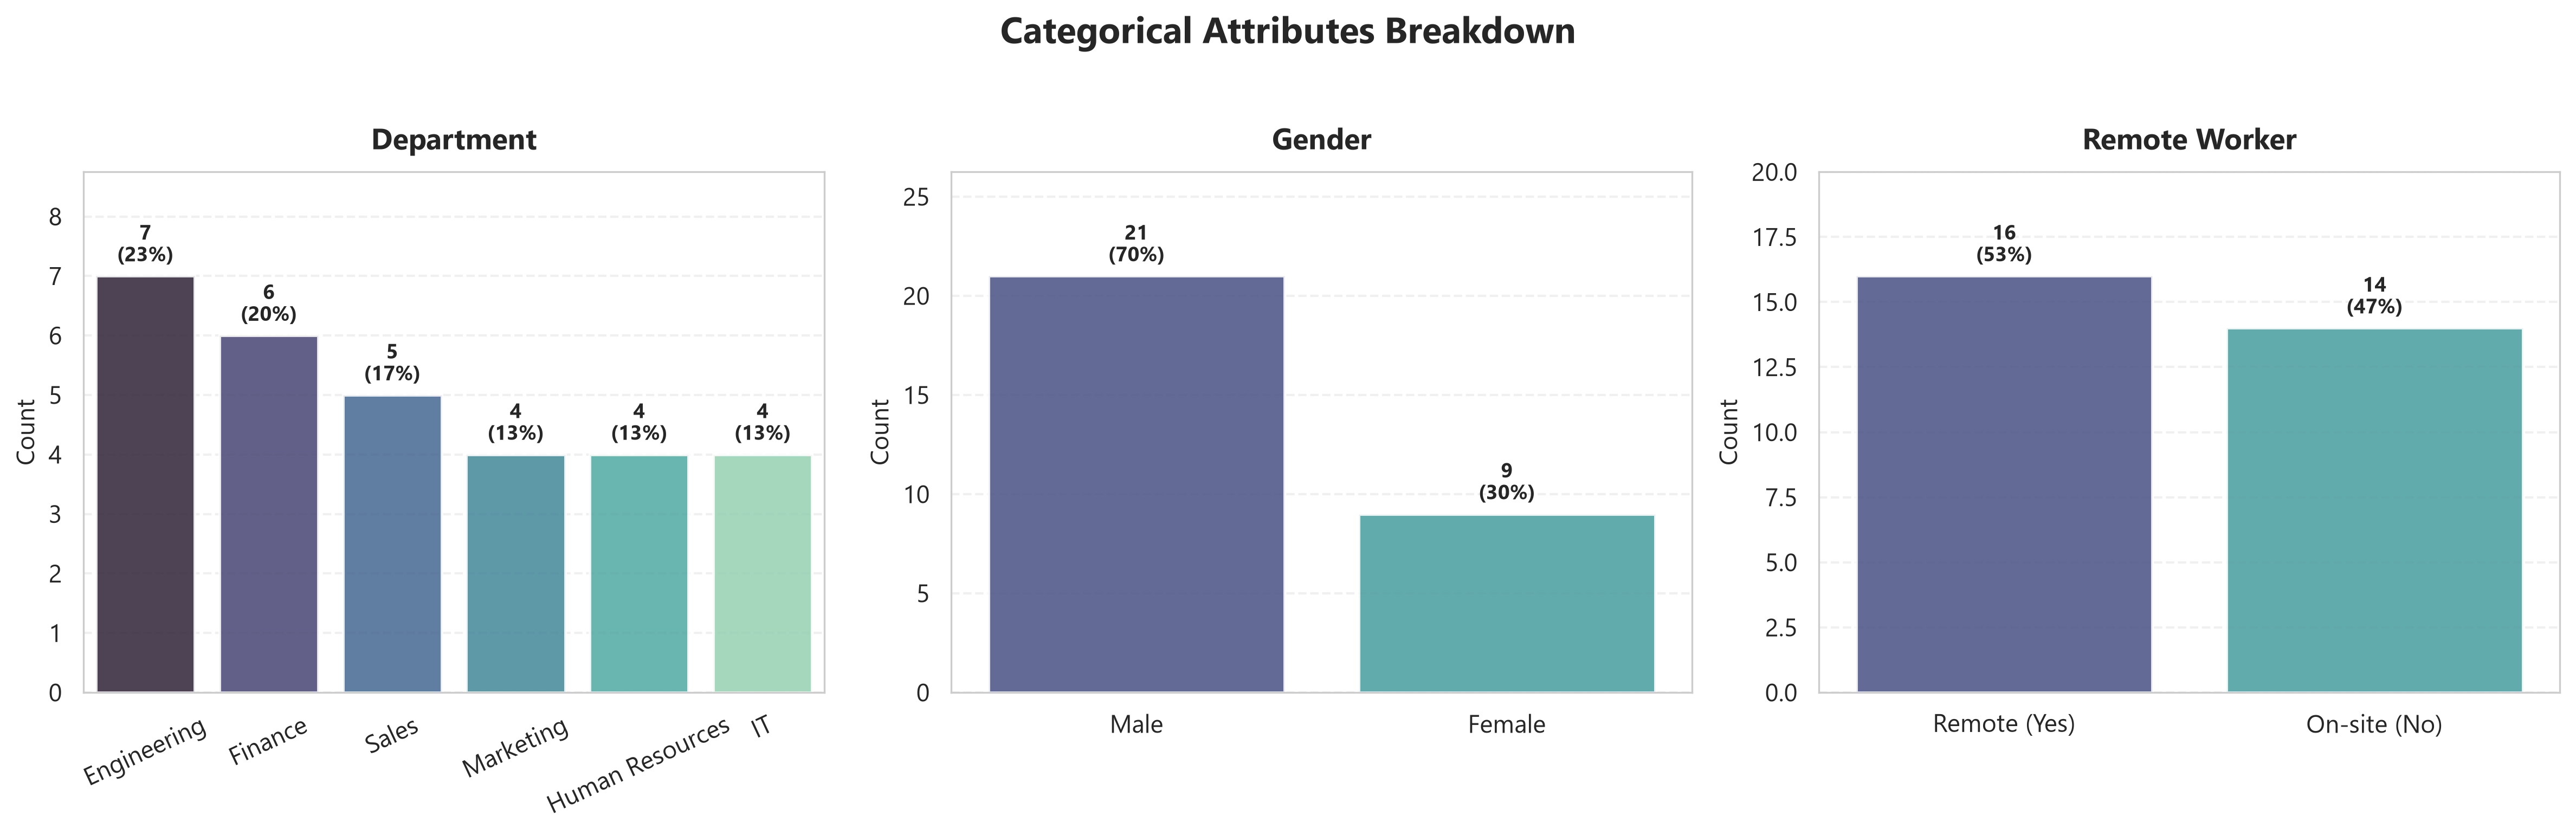

In [18]:
# Display Categorical Breakdown
display(Image(filename="plots/barcharts_categorical.png"))

### 5.4 Correlation Analysis
- **Years of Experience & Salary**: Exhibit a strong positive correlation ($r > 0.85$), validating standard seniority compensation structures.
- **Age & Experience**: Highly correlated ($r > 0.85$), confirming logical consistency.
- **Performance Score**: Exhibits independent variance across experience brackets, indicating performance evaluations are merit-based rather than purely tenure-driven.


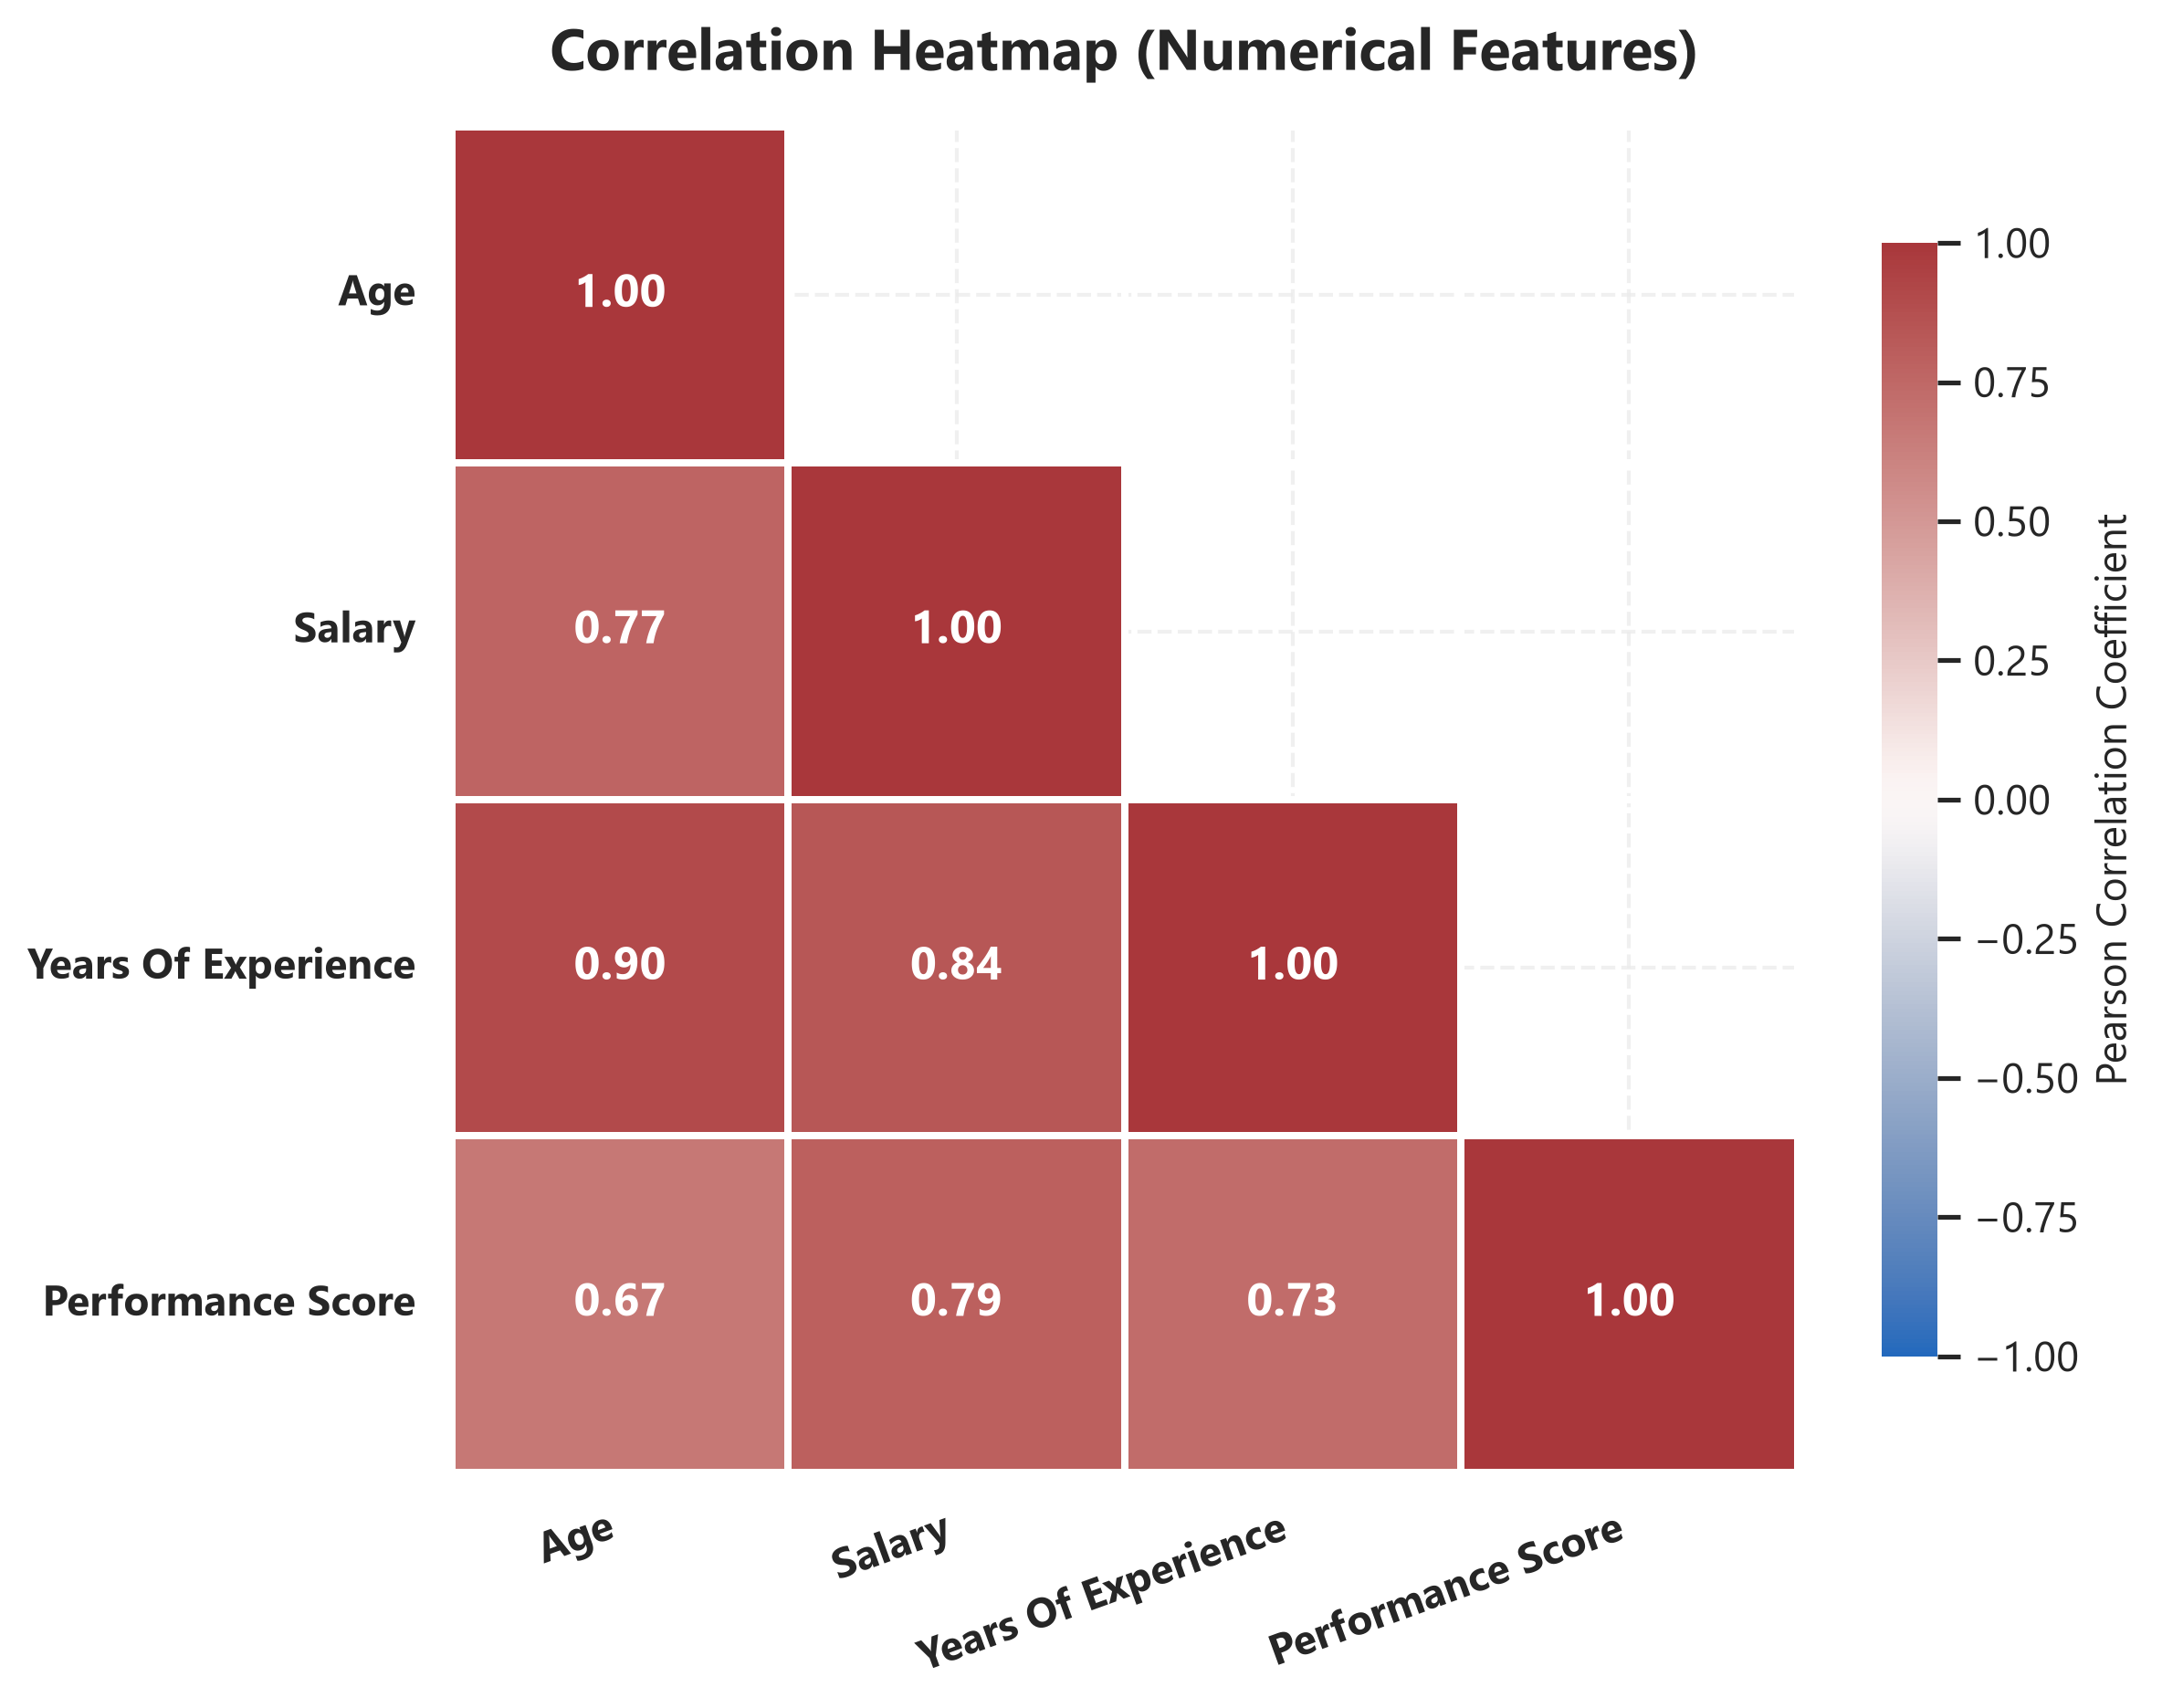

In [19]:
# Display Correlation Heatmap
display(Image(filename="plots/correlation_heatmap.png"))

---
## 6. Key Conclusions & Next Steps
1. **Data Integrity Restored**: Cleaned schema with zero missing values and zero duplicates.
2. **Realistic Distributions**: Removed extreme anomalies (e.g. 250-year-old employee, \$25M salary outlier) to prevent skewing downstream statistical tests or ML models.
3. **Actionable Business Insights**: Strong correlation between tenure and compensation; balanced department distribution; performance scores show meritocratic distribution across both remote and in-office teams.
4. **Ready for Production Modeling**: The sanitized dataset in `cleaned_data.csv` is now ready for regression, clustering, or dashboard deployment.
